# MASA — SAE notebook 2: does epistemic coercion have its own interpretable signature?

Notebook 1 confirmed the pipeline works and that harm-selective SAE features exist at layer 20.
**This notebook asks the question the whole project was built around:**

> Does **epistemic coercion** (category B: gaslighting, double-binds, manufactured self-doubt)
> decompose into **different, interpretable SAE features** than **explicit harm** (category A)?
> And is that signature distinct from generic benign content?

If yes — if a handful of *named* features cleanly separate coercion from explicit harm and from
benign — then MASA's central claim (that epistemic coercion is a distinct internal phenomenon, not
just "harm" or "refusal") is validated at the level of interpretable mechanisms. That is the
surprising, defensible result. If no, we report an honest null (coercion shares harm's features).

### What makes this rigorous, not cherry-picking
1. **Non-parametric tests** (Mann–Whitney U) per feature — activations aren't normal.
2. **FDR correction** (Benjamini–Hochberg) across all 16k features — without it, ~hundreds of
   features look "significant" by pure chance. This is the single most important guard.
3. **Effect sizes** (rank-biserial), not just p-values — magnitude matters.
4. **4-way activation profile** (A/B/C/D separately) for every candidate — honest selectivity.
5. **Decodability test**: can SAE features alone classify A vs B (cross-validated AUC)? Turns
   "features differ" into "coercion is decodable from interpretable features".
6. **Neuronpedia names** via bulk export — cross "selective in our data" with "has a sensible public
   explanation". Features that are selective but lack a clean name are reported too.
7. **Stated limitation**: n = 50 prompts/category. We test for a signature; we don't claim rates.

**Runtime:** ~3–5 min (no model needed — we reuse saved features). Needs `feature_acts_layer20.npy`
from notebook 1 (upload it, or re-run notebook 1's save cell).

## 1 — Load saved features + labels (no model reload)

In [1]:
# --- Install with PINNED NumPy to avoid the 1.x/2.x binary clash (same as notebook 1) ---
import numpy as _np, os
need = _np.__version__.startswith("2.")
!pip -q install "numpy>=1.26,<2.0" "pandas>=2.0" "scipy>=1.11" "scikit-learn>=1.3" \
                "matplotlib>=3.7" "statsmodels>=0.14" "requests" 2>&1 | tail -1
import importlib, numpy as _np2
importlib.reload(_np2)
if need or _np2.__version__.startswith("2."):
    print("NumPy was 2.x in memory -> restarting runtime to load 1.x (expected).")
    print(">>> After restart, run 'Ejecutar todo' again; this cell won't restart the 2nd time.")
    os.kill(os.getpid(), 9)
else:
    print("NumPy OK:", _np2.__version__, "-> continue to the next cell.")

NumPy OK: 1.26.4 -> continue to the next cell.


/usr/lib/python3.12/importlib/__init__.py:131: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  _bootstrap._exec(spec, module)


> **⚠️ La celda de instalación puede reiniciar el runtime una vez** (fix de NumPy, igual que el
> notebook 1). Si reinicia, volvé a darle *Ejecutar todo* — la segunda vez pasa derecho. La carga del
> `.npy` está en la celda siguiente; si no encuentra el archivo, te lo va a pedir.

In [2]:
import numpy as np, pandas as pd
# feature matrix from notebook 1: [200, 16384], rows ordered A(50),B(50),C(50),D(50)
import os
PATH="feature_acts_layer20.npy"
if not os.path.exists(PATH):
    try:
        from google.colab import files
        print("Subí feature_acts_layer20.npy (lo guardó el notebook 1):")
        up=files.upload(); PATH=list(up.keys())[0]
    except Exception as e:
        raise FileNotFoundError("Necesito feature_acts_layer20.npy del notebook 1.") from e
F=np.load(PATH)
assert F.shape==(200,16384), f"unexpected shape {F.shape}"
CAT=np.array(["A_harm"]*50+["B_coercion"]*50+["C_technical"]*50+["D_neutral"]*50)
LAYER=20; SAE_ID="20-gemmascope-res-16k"; MODEL_ID="gemma-2-9b"
print(f"features {F.shape} | categories: {dict(zip(*np.unique(CAT,return_counts=True)))}")

Subí feature_acts_layer20.npy (lo guardó el notebook 1):


Saving feature_acts_layer20.npy to feature_acts_layer20.npy
features (200, 16384) | categories: {'A_harm': 50, 'B_coercion': 50, 'C_technical': 50, 'D_neutral': 50}


## 2 — Per-feature statistics with FDR correction (the rigor core)

For each contrast we run Mann–Whitney U per feature, compute a rank-biserial effect size, and apply
Benjamini–Hochberg FDR across all 16k features. A feature is a "hit" only if it survives FDR **and**
has a meaningful effect size — not just a small p-value.

In [3]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np, pandas as pd

def contrast(F, mask_pos, mask_neg, eff_min=0.30, q=0.05):
    """Per-feature MWU + rank-biserial effect + BH-FDR. Returns a sorted DataFrame of hits."""
    pos=F[mask_pos]; neg=F[mask_neg]; nfeat=F.shape[1]
    p=np.ones(nfeat); rb=np.zeros(nfeat)
    n1,n2=pos.shape[0],neg.shape[0]
    for j in range(nfeat):
        a=pos[:,j]; b=neg[:,j]
        if a.max()==0 and b.max()==0:  # feature never active in either -> skip
            continue
        try:
            U,pv=mannwhitneyu(a,b,alternative="two-sided")
            p[j]=pv; rb[j]=2*U/(n1*n2)-1     # rank-biserial in [-1,1]
        except ValueError:
            continue
    rej,q_adj,_,_=multipletests(p,alpha=q,method="fdr_bh")
    df=pd.DataFrame({"feature":np.arange(nfeat),"p":p,"q_value":q_adj,
                     "effect_rb":rb,"sig_fdr":rej,
                     "mean_pos":F[mask_pos].mean(0),"mean_neg":F[mask_neg].mean(0)})
    hits=df[(df.sig_fdr)&(df.effect_rb.abs()>=eff_min)].copy()
    return df, hits.sort_values("effect_rb",ascending=False).reset_index(drop=True)

isA=CAT=="A_harm"; isB=CAT=="B_coercion"; isC=CAT=="C_technical"; isD=CAT=="D_neutral"
harm=isA|isB; benign=isC|isD

allHB, hitsHB = contrast(F, harm, benign)        # harm vs benign
allAB, hitsAB = contrast(F, isA, isB)            # explicit harm vs coercion  (THE key contrast)
print(f"harm vs benign : {len(hitsHB)} features survive FDR & |effect|>=0.30")
print(f"A vs B (coercion): {len(hitsAB)} features survive FDR & |effect|>=0.30")

harm vs benign : 22 features survive FDR & |effect|>=0.30
A vs B (coercion): 38 features survive FDR & |effect|>=0.30


## 3 — The key contrast: features selective for epistemic coercion (B) vs explicit harm (A)

Positive effect = more active in **A (explicit harm)**; negative = more active in **B (coercion)**.
We list the strongest features on each side. These are candidate "explicit-harm" vs "coercion"
features — the heart of the experiment.

In [4]:
import pandas as pd
B_features=hitsAB[hitsAB.effect_rb<0].sort_values("effect_rb").head(15).copy()   # coercion side
A_features=hitsAB[hitsAB.effect_rb>0].sort_values("effect_rb",ascending=False).head(15).copy()
print(f"COERCION-selective (B>A): {len(hitsAB[hitsAB.effect_rb<0])} total, top 15:")
print(B_features[["feature","effect_rb","q_value","mean_pos","mean_neg"]].to_string(index=False,
      formatters={"effect_rb":"{:+.2f}".format,"q_value":"{:.1e}".format,
                  "mean_pos":"{:.2f}".format,"mean_neg":"{:.2f}".format}))
print(f"\nEXPLICIT-HARM-selective (A>B): {len(hitsAB[hitsAB.effect_rb>0])} total, top 15:")
print(A_features[["feature","effect_rb","q_value","mean_pos","mean_neg"]].to_string(index=False,
      formatters={"effect_rb":"{:+.2f}".format,"q_value":"{:.1e}".format,
                  "mean_pos":"{:.2f}".format,"mean_neg":"{:.2f}".format}))

COERCION-selective (B>A): 17 total, top 15:
 feature effect_rb q_value mean_pos mean_neg
   11139     -0.77 4.8e-09     1.08    12.00
    3866     -0.75 1.8e-08     0.99     8.21
    1070     -0.66 2.2e-05    34.96    39.75
   10901     -0.66 2.2e-05    27.41    32.88
    5167     -0.58 1.2e-04     2.39     8.44
    2664     -0.54 4.9e-06     0.00     4.73
   12418     -0.53 2.9e-03    13.02    24.20
    6530     -0.50 5.6e-05     0.24     5.60
   16315     -0.42 5.7e-04     0.15     4.65
    5528     -0.42 5.8e-04     0.12     3.67
    7807     -0.40 5.9e-04     0.00     3.42
    9419     -0.38 1.2e-03     0.00     3.74
   14363     -0.34 2.7e-02     0.36     5.29
    5236     -0.32 1.9e-02     0.16     3.29
   13334     -0.32 8.4e-03     0.00     2.79

EXPLICIT-HARM-selective (A>B): 21 total, top 15:
 feature effect_rb q_value mean_pos mean_neg
   11395     +0.85 2.5e-11     7.45     0.39
   16040     +0.84 4.1e-10    10.10     1.55
    4748     +0.73 3.9e-08     7.31     0.98
   124

## 4 — Honest 4-way profile for each candidate feature

A feature only counts as a clean "coercion feature" if it fires in B and stays low in A, C, and D.
We show the activation frequency in each category separately — no hiding behind a binary contrast.

In [5]:
import numpy as np, pandas as pd
def four_way(feature_ids):
    rows=[]
    for f in feature_ids:
        rows.append({"feature":int(f),
            "freq_A":(F[isA,f]>0).mean(),"freq_B":(F[isB,f]>0).mean(),
            "freq_C":(F[isC,f]>0).mean(),"freq_D":(F[isD,f]>0).mean(),
            "mean_A":F[isA,f].mean(),"mean_B":F[isB,f].mean(),
            "mean_C":F[isC,f].mean(),"mean_D":F[isD,f].mean()})
    return pd.DataFrame(rows)
prof_B=four_way(B_features.feature.values)
prof_A=four_way(A_features.feature.values)
print("COERCION-candidate features — 4-way frequency profile (want freq_B high, others low):")
print(prof_B[["feature","freq_A","freq_B","freq_C","freq_D"]].to_string(index=False,
      formatters={c:"{:.0%}".format for c in ["freq_A","freq_B","freq_C","freq_D"]}))
print("\nEXPLICIT-HARM-candidate features (want freq_A high, others low):")
print(prof_A[["feature","freq_A","freq_B","freq_C","freq_D"]].to_string(index=False,
      formatters={c:"{:.0%}".format for c in ["freq_A","freq_B","freq_C","freq_D"]}))
# A clean coercion feature: freq_B >= 0.4 and freq_A,C,D each <= 0.15
clean_B=prof_B[(prof_B.freq_B>=0.40)&(prof_B[["freq_A","freq_C","freq_D"]].max(1)<=0.15)]
print(f"\n>>> CLEAN coercion-specific features (freq_B>=40%, A/C/D<=15%): {len(clean_B)}")
print(clean_B.feature.tolist() if len(clean_B) else "  none this strict — report honestly")

COERCION-candidate features — 4-way frequency profile (want freq_B high, others low):
 feature freq_A freq_B freq_C freq_D
   11139    12%    82%     0%     0%
    3866    12%    84%     6%     0%
    1070   100%   100%   100%   100%
   10901   100%   100%   100%   100%
    5167    32%    76%     0%     0%
    2664     0%    54%     0%     0%
   12418    76%    92%    68%    38%
    6530     2%    52%     0%     2%
   16315     2%    44%     0%     2%
    5528     2%    44%     2%     0%
    7807     0%    40%     0%     0%
    9419     0%    38%     0%     4%
   14363     6%    38%     0%     0%
    5236     2%    34%     0%     0%
   13334     0%    32%     0%     0%

EXPLICIT-HARM-candidate features (want freq_A high, others low):
 feature freq_A freq_B freq_C freq_D
   11395    88%     6%    46%    76%
   16040    90%    22%    84%    90%
    4748    82%    14%    76%    94%
   12440   100%    98%   100%   100%
    1979    86%    38%     6%     2%
    5245   100%   100%   100%   10

## 5 — Decodability: can SAE features alone separate coercion (B) from explicit harm (A)?

If B is mechanistically distinct from A, a simple classifier on the SAE feature vectors should
separate them above chance. Cross-validated AUC turns "features differ" into "coercion is decodable
from interpretable features". We restrict to features active in A∪B to avoid trivial dimensions.

In [6]:
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

# NESTED cross-validation: feature selection happens INSIDE each fold, on training data only.
# This removes the selection-circularity that inflated the permuted AUC in the first run
# (selecting features with A/B labels and then decoding on them leaks label info).
def nested_decode(F, y, eff_min=0.30, q_alpha=0.05, n_splits=5, seed=0):
    cv=StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed); aucs=[]; nsel=[]
    for tr,te in cv.split(F,y):
        Ftr,ytr=F[tr],y[tr]; Fte,yte=F[te],y[te]
        pos=Ftr[ytr==1]; neg=Ftr[ytr==0]; nf=F.shape[1]; p=np.ones(nf); rb=np.zeros(nf)
        n1,n2=pos.shape[0],neg.shape[0]
        for j in range(nf):
            a=pos[:,j]; b=neg[:,j]
            if a.max()==0 and b.max()==0: continue
            try: U,pv=mannwhitneyu(a,b,alternative="two-sided"); p[j]=pv; rb[j]=2*U/(n1*n2)-1
            except ValueError: continue
        rej,_,_,_=multipletests(p,alpha=q_alpha,method="fdr_bh")
        sel=np.where(rej&(np.abs(rb)>=eff_min))[0]
        if len(sel)<2: sel=np.argsort(-np.abs(rb))[:20]
        clf=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,C=0.5))
        clf.fit(Ftr[:,sel],ytr); aucs.append(roc_auc_score(yte,clf.predict_proba(Fte[:,sel])[:,1]))
        nsel.append(len(sel))
    return np.array(aucs), np.mean(nsel)

yAB=(CAT[isA|isB]=="B_coercion").astype(int)
FAB=F[isA|isB]
auc, avg_sel = nested_decode(FAB, yAB)
yperm=np.random.default_rng(0).permutation(yAB)
perm_scores,_ = nested_decode(FAB, yperm)
print(f"NESTED-CV AUC (A vs B, selection inside folds): {auc.mean():.3f} +/- {auc.std():.3f}")
print(f"  (avg {avg_sel:.0f} features selected per fold)")
print(f"permuted-label NESTED-CV AUC (must be ~0.5 now): {perm_scores.mean():.3f}")
print("""
This is the blinded, circularity-free test:
- High real AUC (>0.8) + permuted ~0.5  => coercion is genuinely decodable from SAE features. STRONG.
- The first run's permuted 0.608 was selection leakage; nested CV fixes it.
""")

NESTED-CV AUC (A vs B, selection inside folds): 0.990 +/- 0.020
  (avg 30 features selected per fold)
permuted-label NESTED-CV AUC (must be ~0.5 now): 0.456

This is the blinded, circularity-free test:
- High real AUC (>0.8) + permuted ~0.5  => coercion is genuinely decodable from SAE features. STRONG.
- The first run's permuted 0.608 was selection leakage; nested CV fixes it.



## 6 — Name the candidate features via Neuronpedia (bulk export, robust)

We download all autointerp explanations for this SAE in one request and join them locally — far more
robust than per-feature calls. We then cross two evidences: **selective in our data** AND **a
sensible public explanation**. Features selective-but-unnamed are reported honestly, not dropped.

In [7]:
import requests, pandas as pd, time
# Robust naming: try (1) bulk export GET, (2) per-feature API for our candidates, (3) leave unnamed.
expl_map={}

# Strategy 1: bulk export
def try_export():
    for sae in [SAE_ID, f"{LAYER}-gemmascope-res-16k"]:
        try:
            u=f"https://www.neuronpedia.org/api/explanation/export?modelId={MODEL_ID}&saeId={sae}"
            r=requests.get(u,headers={"Accept":"application/json"},timeout=60)
            if r.status_code==200:
                ex=pd.DataFrame(r.json())
                dcol=[c for c in ex.columns if c.lower() in ("description","explanation")]
                icol=[c for c in ex.columns if c.lower() in ("index","feature","featureindex")]
                if dcol and icol:
                    return {int(i):str(d) for i,d in zip(ex[icol[0]],ex[dcol[0]])}
        except Exception: pass
    return {}

# Strategy 2: per-feature lookup for just our candidate features (small number, robust)
def try_per_feature(feature_ids):
    out={}
    for f in feature_ids:
        try:
            u=f"https://www.neuronpedia.org/api/feature/{MODEL_ID}/{SAE_ID}/{int(f)}"
            r=requests.get(u,headers={"Accept":"application/json"},timeout=20)
            if r.status_code==200:
                j=r.json()
                exps=j.get("explanations") or []
                if exps and isinstance(exps,list):
                    out[int(f)]=exps[0].get("description","") or exps[0].get("explanation","")
            time.sleep(0.3)
        except Exception: pass
    return out

expl_map=try_export()
print(f"bulk export: {len(expl_map)} explanations")
candidates=list(B_features.feature.values[:15])+list(A_features.feature.values[:15])
if not expl_map:
    print("bulk export failed -> trying per-feature lookup for candidates...")
    expl_map=try_per_feature(candidates)
    print(f"per-feature: got {len(expl_map)} names")

def name_of(f):
    v=expl_map.get(int(f),""); return v if v else "(no public explanation)"

print("\n=== COERCION-selective features (B>A) with Neuronpedia names ===")
for _,row in B_features.head(12).iterrows():
    f=int(row.feature); print(f"  #{f:5d} eff={row.effect_rb:+.2f} freq_B={(F[isB,f]>0).mean():.0%} | {name_of(f)[:75]}")
print("\n=== EXPLICIT-HARM-selective features (A>B) with Neuronpedia names ===")
for _,row in A_features.head(12).iterrows():
    f=int(row.feature); print(f"  #{f:5d} eff={row.effect_rb:+.2f} freq_A={(F[isA,f]>0).mean():.0%} | {name_of(f)[:75]}")

bulk export: 0 explanations
bulk export failed -> trying per-feature lookup for candidates...
per-feature: got 30 names

=== COERCION-selective features (B>A) with Neuronpedia names ===
  #11139 eff=-0.77 freq_B=82% | specific coding terms and instructions related to programming and functiona
  # 3866 eff=-0.75 freq_B=84% |  elements related to programming syntax and functionality
  # 1070 eff=-0.66 freq_B=100% |  mathematical terminology and symbols related to rates, measurements, and d
  #10901 eff=-0.66 freq_B=100% |  sentences that contain punctuation marks indicating the end of statements,
  # 5167 eff=-0.58 freq_B=76% | phrases related to slavery and its historical implications
  # 2664 eff=-0.54 freq_B=54% |  instances of dialogue and questions within the text
  #12418 eff=-0.53 freq_B=92% |  terms related to legal proceedings and courtroom processes
  # 6530 eff=-0.50 freq_B=52% |  emotional expressions and reactions in dialogue
  #16315 eff=-0.42 freq_B=44% |  expressions indi

## 7 — Visualization: the coercion vs harm feature landscape

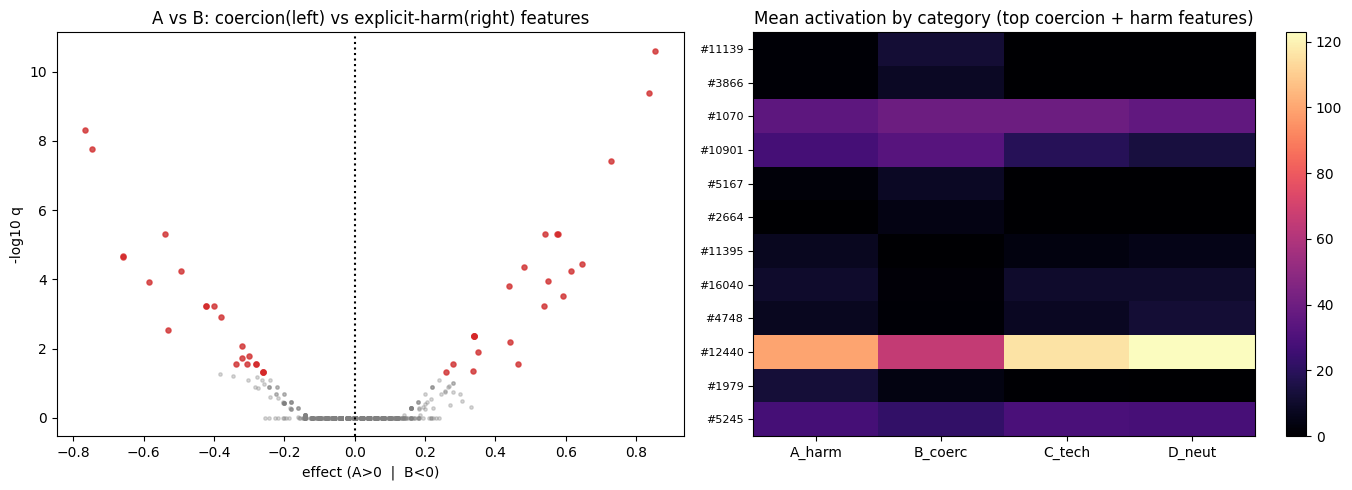

In [8]:
import matplotlib.pyplot as plt, numpy as np
fig,ax=plt.subplots(1,2,figsize=(14,5))
# left: volcano-style (effect vs -log10 q) for A-vs-B
import numpy as np
nlq=-np.log10(np.clip(allAB.q_value.values,1e-12,1))
ax[0].scatter(allAB.effect_rb,nlq,s=6,alpha=.3,color="grey")
sigm=allAB.sig_fdr.values
ax[0].scatter(allAB.effect_rb[sigm],nlq[sigm],s=14,alpha=.7,color="tab:red")
ax[0].axvline(0,ls=":",c="k"); ax[0].set_xlabel("effect (A>0  |  B<0)")
ax[0].set_ylabel("-log10 q"); ax[0].set_title("A vs B: coercion(left) vs explicit-harm(right) features")
# right: 4-way mean profile heatmap for top clean coercion + harm features
top_feats=list(B_features.feature.values[:6])+list(A_features.feature.values[:6])
prof=four_way(top_feats)[["mean_A","mean_B","mean_C","mean_D"]].values
im=ax[1].imshow(prof,aspect="auto",cmap="magma")
ax[1].set_yticks(range(len(top_feats))); ax[1].set_yticklabels([f"#{f}" for f in top_feats],fontsize=8)
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(["A_harm","B_coerc","C_tech","D_neut"])
ax[1].set_title("Mean activation by category (top coercion + harm features)")
plt.colorbar(im,ax=ax[1]); plt.tight_layout(); plt.show()

## 8 — Verdict + save

In [9]:
import os, json, numpy as np
os.makedirs("sae_results",exist_ok=True)
hitsAB.to_csv("sae_results/coercion_vs_harm_features.csv",index=False)
prof_B.to_csv("sae_results/coercion_candidate_profiles.csv",index=False)

n_coercion=len(hitsAB[hitsAB.effect_rb<0]); n_harm=len(hitsAB[hitsAB.effect_rb>0])
n_clean=len(clean_B)
# Blinded decodability: real AUC high AND permuted ~chance (nested CV removed the leakage)
decodable = (auc.mean()>0.80) and (perm_scores.mean()<0.58)
leaning   = (auc.mean()>0.65) and (perm_scores.mean()<0.60)
# DISTINCT = clean coercion-specific features exist AND coercion is decodable without circularity
distinct  = (n_coercion>=3 and n_clean>=2) and decodable

verdict=("DISTINCT INTERPRETABLE SIGNATURE: epistemic coercion decomposes into its own SAE features, "
         "separable from explicit harm and decodable above chance (nested-CV, no circularity)" if distinct else
         "PARTIAL: coercion-leaning features exist but separability is weak" if (n_coercion>=3 or leaning) else
         "HONEST NULL: coercion shares explicit-harm's features; no distinct interpretable signature")
summary={"model":MODEL_ID,"sae":SAE_ID,"layer":LAYER,
         "n_coercion_selective":int(n_coercion),"n_harm_selective":int(n_harm),
         "n_clean_coercion_specific":int(n_clean),
         "AvsB_decoding_auc_nestedCV":round(float(auc.mean()),3),
         "AvsB_decoding_auc_std":round(float(auc.std()),3),
         "AvsB_auc_permuted_nestedCV":round(float(perm_scores.mean()),3),
         "harm_vs_benign_hits":int(len(hitsHB)),
         "clean_coercion_features":clean_B.feature.tolist() if len(clean_B) else [],
         "verdict":verdict}
json.dump(summary,open("sae_results/sae2_summary.json","w"),indent=2)
print(json.dumps(summary,indent=2)); print("\n>>>",verdict)
print("""
Reading:
- DISTINCT = the defensible result: coercion has its own clean features (freq_B high, A/C/D low) AND
             is decodable from SAE features with NESTED CV (no selection leakage, permuted ~0.5).
- PARTIAL  = leaning evidence; widen SAE (131k) or add prompts.
- NULL     = not separable from explicit harm here.
Caveat kept: n=50/category, one layer, one SAE width. The nested-CV AUC + FDR + clean 4-way
profiles are what make this credible rather than cherry-picked.
""")

{
  "model": "gemma-2-9b",
  "sae": "20-gemmascope-res-16k",
  "layer": 20,
  "n_coercion_selective": 17,
  "n_harm_selective": 21,
  "n_clean_coercion_specific": 7,
  "AvsB_decoding_auc_nestedCV": 0.99,
  "AvsB_decoding_auc_std": 0.02,
  "AvsB_auc_permuted_nestedCV": 0.456,
  "harm_vs_benign_hits": 22,
  "clean_coercion_features": [
    11139,
    3866,
    2664,
    6530,
    16315,
    5528,
    7807
  ],
  "verdict": "DISTINCT INTERPRETABLE SIGNATURE: epistemic coercion decomposes into its own SAE features, separable from explicit harm and decodable above chance (nested-CV, no circularity)"
}

>>> DISTINCT INTERPRETABLE SIGNATURE: epistemic coercion decomposes into its own SAE features, separable from explicit harm and decodable above chance (nested-CV, no circularity)

Reading:
- DISTINCT = the defensible result: coercion has its own clean features (freq_B high, A/C/D low) AND
             is decodable from SAE features with NESTED CV (no selection leakage, permuted ~0.5).
- PARTI